In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
path = kagglehub.dataset_download(
    "izzulhaqmahardika/coco-vehicles-car-bus-truck-motorcycle"
)

print(path)

100%|██████████| 3.17G/3.17G [00:37<00:00, 89.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/izzulhaqmahardika/coco-vehicles-car-bus-truck-motorcycle/versions/1


In [ ]:
import os

print(os.listdir(path))

['instances_train2017_vehicles.json', 'val2017_vehicles', 'instances_val2017_vehicles.json', 'train2017_vehicles', 'dataset-metadata.json']


In [ ]:
import kagglehub

path = kagglehub.dataset_download("izzulhaqmahardika/coco-vehicles-car-bus-truck-motorcycle")

In [ ]:
import os

train_path = os.path.join(path, "train2017_vehicles")
val_path = os.path.join(path, "val2017_vehicles")

print("Training images:", len(os.listdir(train_path)))
print("Validation images:", len(os.listdir(val_path)))

Training images: 18175
Validation images: 796


In [ ]:
import json

train_json = os.path.join(
    path,
    "instances_train2017_vehicles.json"
)

with open(train_json, "r") as f:
    train_data = json.load(f)

print(train_data.keys())

dict_keys(['images', 'annotations', 'categories'])


In [ ]:
print(train_data["categories"])

[{'supercategory': 'vehicle', 'id': 3, 'name': 'car'}, {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'}, {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'}, {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'}]


In [ ]:
from collections import Counter

category_names = {
    3: "car",
    4: "motorcycle",
    6: "bus",
    8: "truck"
}

category_count = Counter()

for annotation in train_data["annotations"]:
    category_id = annotation["category_id"]

    if category_id in category_names:
        category_count[category_names[category_id]] += 1

print(category_count)

Counter({'car': 43867, 'truck': 9973, 'motorcycle': 8725, 'bus': 6069})


In [ ]:
import os

base_dir = "/content/vehicle_classification"

classes = ["car", "truck", "motorcycle", "bus"]

for class_name in classes:
    os.makedirs(os.path.join(base_dir, class_name), exist_ok=True)

print("Class folders created successfully!")

Class folders created successfully!


In [ ]:
from PIL import Image
import os
import json

train_json = os.path.join(path, "instances_train2017_vehicles.json")
train_images = os.path.join(path, "train2017_vehicles")

with open(train_json, "r") as f:
    train_data = json.load(f)

print("Images:", len(train_data["images"]))
print("Annotations:", len(train_data["annotations"]))

Images: 18175
Annotations: 68634


In [ ]:
from PIL import Image

category_names = {
    3: "car",
    4: "motorcycle",
    6: "bus",
    8: "truck"
}

image_info = {}

for image in train_data["images"]:
    image_info[image["id"]] = image["file_name"]

count = {
    "car": 0,
    "truck": 0,
    "motorcycle": 0,
    "bus": 0
}

for annotation in train_data["annotations"]:

    category_id = annotation["category_id"]

    if category_id not in category_names:
        continue

    class_name = category_names[category_id]

    if count[class_name] >= 5000:
        continue

    image_id = annotation["image_id"]
    image_name = image_info[image_id]

    image_path = os.path.join(train_images, image_name)

    try:
        image = Image.open(image_path).convert("RGB")

        x, y, width, height = annotation["bbox"]

        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(image.width, int(x + width))
        y2 = min(image.height, int(y + height))

        if x2 <= x1 or y2 <= y1:
            continue

        cropped = image.crop((x1, y1, x2, y2))

        save_name = f"{class_name}_{count[class_name]}.jpg"

        save_path = os.path.join(
            base_dir,
            class_name,
            save_name
        )

        cropped.save(save_path)

        count[class_name] += 1

    except Exception:
        continue

print("Cropping completed!")
print(count)

Cropping completed!
{'car': 5000, 'truck': 5000, 'motorcycle': 5000, 'bus': 5000}


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 16000 images belonging to 4 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4000 images belonging to 4 classes.


In [ ]:
class_indices = train_generator.class_indices

class_names = list(class_indices.keys())

print("Class indices:", class_indices)
print("Class names:", class_names)

Class indices: {'bus': 0, 'car': 1, 'motorcycle': 2, 'truck': 3}
Class names: ['bus', 'car', 'motorcycle', 'truck']


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(224, 224, 3)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128, (3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.5685 - loss: 1.0088 - val_accuracy: 0.6530 - val_loss: 0.8519
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.6972 - loss: 0.7489 - val_accuracy: 0.6720 - val_loss: 0.8230
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.7771 - loss: 0.5611 - val_accuracy: 0.6525 - val_loss: 0.9370
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.8649 - loss: 0.3500 - val_accuracy: 0.6580 - val_loss: 1.0586
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9341 - loss: 0.1818 - val_accuracy: 0.6338 - val_loss: 1.4803
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.9666 - loss: 0.0980 - val_accuracy: 0.6490 - val_loss: 1.7608
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9778 - loss: 0.0688 - val_accuracy: 0.6467 - val_loss: 2.0929
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9818 - loss: 0.0557 - 

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save('/content/drive/MyDrive/vehicle_classification.h5')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/vehicle_classification.h5')

print("Model Loaded")

Model Loaded


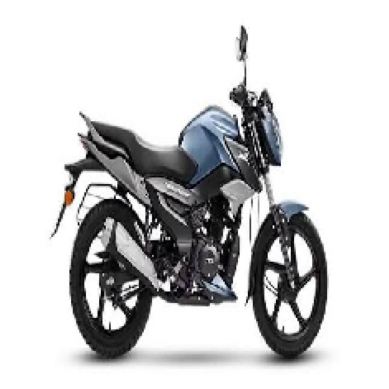

In [ ]:
from tensorflow.keras.preprocessing import image
from matplotlib import pyplot as plt

test_image_path = "/content/drive/MyDrive/images (1).jpg"

img = image.load_img(
    test_image_path,
    target_size=(224, 224)
)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array /= 255.0

In [ ]:
prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
[[5.1812805e-07 1.4773516e-04 9.9982262e-01 2.9197090e-05]]


In [ ]:
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Vehicle:", predicted_class)

Predicted Vehicle: motorcycle
